In [1]:
import sys, os, yaml
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

# Thêm đường dẫn src vào hệ thống
sys.path.append(os.path.abspath(os.path.join('..')))

from src.models.supervised import prepare_classification_data, train_classifiers
from src.models.handler import save_model_artifact
from src.visualization.plots import plot_confusion_matrix
from sklearn.metrics import classification_report, f1_score

# Load Config
with open('../configs/params.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

# Đọc dữ liệu đã tiền xử lý (đã có Month, Season, Precip Type='none'...)
df = pd.read_csv(f"../{config['processed_data_path']}")

In [2]:
# Chuẩn bị dữ liệu theo logic mới (Lọc nhãn hiếm, mã hóa Precip Type và Summary)
(X_train, X_test, y_train, y_test), le_target = prepare_classification_data(df, config)

num_labels = len(le_target.classes_)
print(f"✅ Dữ liệu sẵn sàng với {num_labels} nhãn Summary.")
print(f"Các nhãn bao gồm: {le_target.classes_}")

✅ Dữ liệu sẵn sàng với 8 nhãn Summary.
Các nhãn bao gồm: ['Breezy and Mostly Cloudy' 'Breezy and Overcast'
 'Breezy and Partly Cloudy' 'Clear' 'Foggy' 'Mostly Cloudy' 'Overcast'
 'Partly Cloudy']


In [3]:
# Huấn luyện đồng thời Random Forest và XGBoost
rf_model, xgb_model = train_classifiers(X_train, y_train, config, num_classes=num_labels)

D:\anaconda3\Lib\site-packages\xgboost\training.py:200: UserWarning: [11:07:39] WARNING: C:\actions-runner\_work\xgboost\xgboost\src\learner.cc:782: 
Parameters: { "use_label_encoder" } are not used.

  bst.update(dtrain, iteration=i, fobj=obj)


## Đánh giá chi tiết Random Forest


==================== BÁO CÁO RANDOM FOREST ====================
                          precision    recall  f1-score   support

Breezy and Mostly Cloudy       0.48      0.53      0.50        92
     Breezy and Overcast       0.66      0.76      0.71       112
Breezy and Partly Cloudy       0.55      0.62      0.58        84
                   Clear       0.39      0.61      0.47      2164
                   Foggy       1.00      1.00      1.00      1406
           Mostly Cloudy       0.53      0.41      0.47      5732
                Overcast       0.52      0.69      0.59      3269
           Partly Cloudy       0.61      0.51      0.56      6320

                accuracy                           0.56     19179
               macro avg       0.59      0.64      0.61     19179
            weighted avg       0.58      0.56      0.56     19179



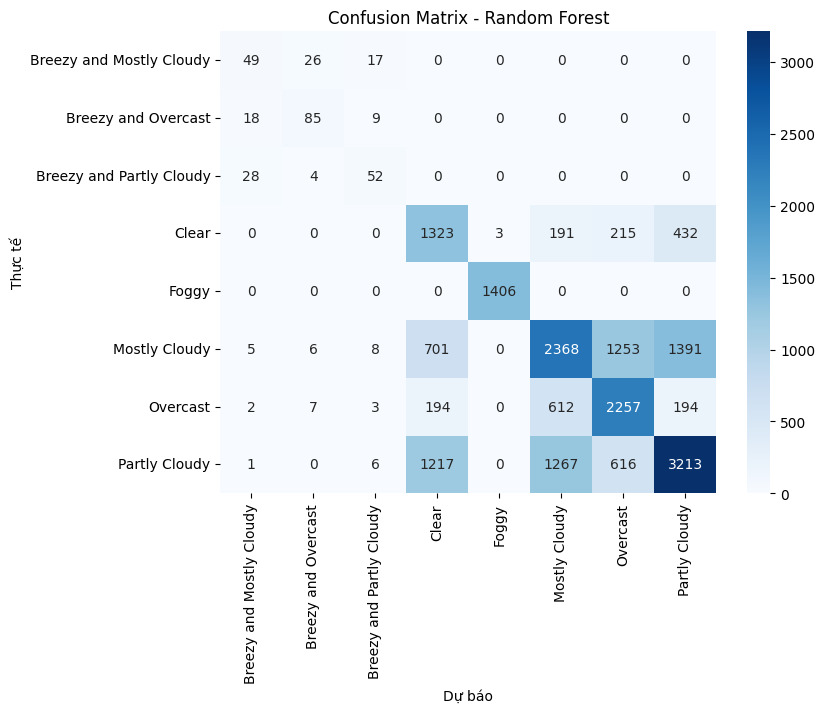

In [4]:
y_pred_rf = rf_model.predict(X_test)

print("\n" + "="*20 + " BÁO CÁO RANDOM FOREST " + "="*20)
print(classification_report(y_test, y_pred_rf, target_names=le_target.classes_))

# Vẽ Confusion Matrix cho RF
plot_confusion_matrix(y_test, y_pred_rf, labels=le_target.classes_, title="Confusion Matrix - Random Forest")

## Đánh giá chi tiết XGBoost


==================== BÁO CÁO XGBOOST ====================
                          precision    recall  f1-score   support

Breezy and Mostly Cloudy       0.41      0.47      0.44        92
     Breezy and Overcast       0.60      0.61      0.60       112
Breezy and Partly Cloudy       0.60      0.58      0.59        84
                   Clear       0.56      0.26      0.36      2164
                   Foggy       0.99      0.99      0.99      1406
           Mostly Cloudy       0.48      0.45      0.47      5732
                Overcast       0.56      0.50      0.53      3269
           Partly Cloudy       0.53      0.69      0.60      6320

                accuracy                           0.56     19179
               macro avg       0.59      0.57      0.57     19179
            weighted avg       0.56      0.56      0.55     19179



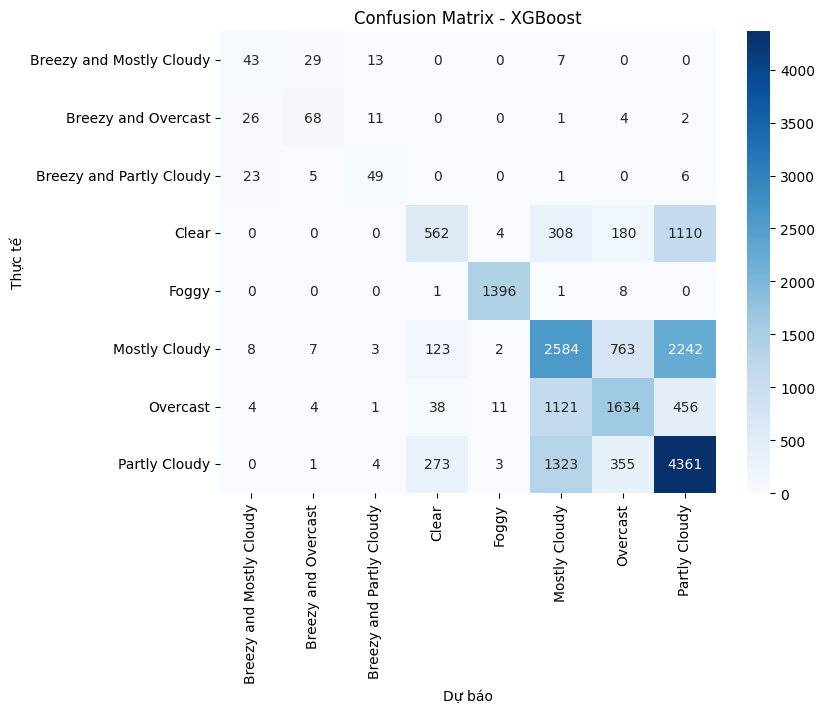

In [5]:
y_pred_xgb = xgb_model.predict(X_test)

print("\n" + "="*20 + " BÁO CÁO XGBOOST " + "="*20)
print(classification_report(y_test, y_pred_xgb, target_names=le_target.classes_))

# Vẽ Confusion Matrix cho XGBoost
plot_confusion_matrix(y_test, y_pred_xgb, labels=le_target.classes_, title="Confusion Matrix - XGBoost")


--- SO SÁNH HIỆU NĂNG ---


,Model,F1-Macro Score
0,Random Forest,0.609829
1,XGBoost,0.571698


C:\Users\toton\AppData\Local\Temp\ipykernel_19028\648486153.py:16: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Model', y='F1-Macro Score', data=comparison_df, palette='viridis')


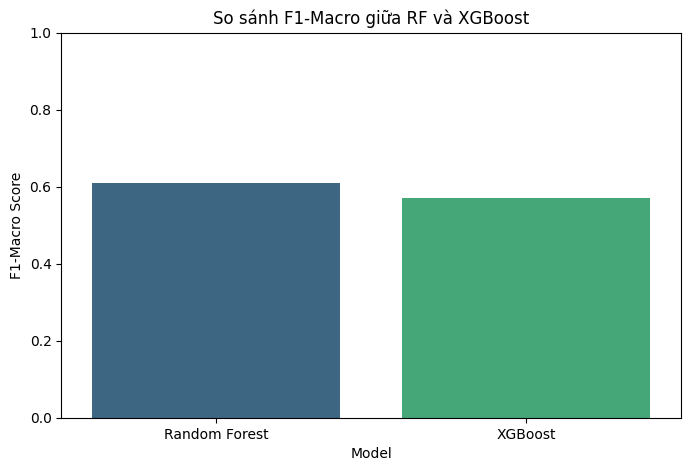

In [6]:
# Tính toán F1-Macro
f1_rf = f1_score(y_test, y_pred_rf, average='macro')
f1_xgb = f1_score(y_test, y_pred_xgb, average='macro')

# Hiển thị bảng so sánh
comparison_df = pd.DataFrame({
    'Model': ['Random Forest', 'XGBoost'],
    'F1-Macro Score': [f1_rf, f1_xgb]
})

print("\n--- SO SÁNH HIỆU NĂNG ---")
display(comparison_df)

# Trực quan hóa so sánh
plt.figure(figsize=(8, 5))
sns.barplot(x='Model', y='F1-Macro Score', data=comparison_df, palette='viridis')
plt.ylim(0, 1)
plt.title("So sánh F1-Macro giữa RF và XGBoost")
plt.show()


⚠️ Tổng số mẫu dự báo sai: 8482 / 19179


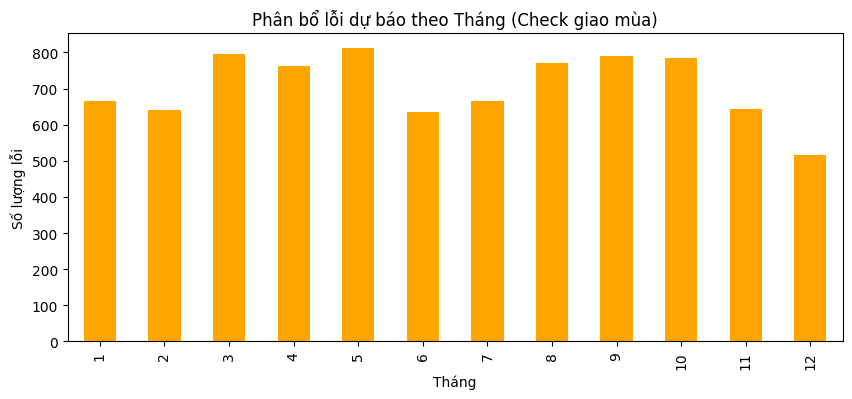


Đặc điểm nhiệt độ tại các mẫu dự báo sai:
count    8482.000000
mean       12.044852
std         8.687881
min       -13.905556
25%         5.923611
50%        12.188889
75%        17.977778
max        38.838889
Name: Temperature (C), dtype: float64


In [7]:
# Tạo dataframe kết quả để phân tích lỗi của model tốt nhất (giả sử là XGBoost)
analysis_df = X_test.copy()
analysis_df['Actual'] = le_target.inverse_transform(y_test)
analysis_df['Predicted'] = le_target.inverse_transform(y_pred_xgb)

# Lọc các dòng dự báo sai
errors = analysis_df[analysis_df['Actual'] != analysis_df['Predicted']].copy()

print(f"\n⚠️ Tổng số mẫu dự báo sai: {len(errors)} / {len(X_test)}")

# Thống kê lỗi theo tháng (Vùng giao mùa)
error_by_month = errors['Month'].value_counts().sort_index()
plt.figure(figsize=(10, 4))
error_by_month.plot(kind='bar', color='orange')
plt.title("Phân bổ lỗi dự báo theo Tháng (Check giao mùa)")
plt.xlabel("Tháng")
plt.ylabel("Số lượng lỗi")
plt.show()

# Kiểm tra lỗi tại vùng nhiệt độ cực trị (ví dụ nhiệt độ thấp)
print("\nĐặc điểm nhiệt độ tại các mẫu dự báo sai:")
print(errors['Temperature (C)'].describe())

In [8]:
# Lưu mô hình vào outputs/models/
save_model_artifact(rf_model, "rf_summary_model", config)
save_model_artifact(xgb_model, "xgb_summary_model", config)

print("\n✅ Đã lưu toàn bộ mô hình và báo cáo.")

📦 Đã lưu mô hình: ../outputs/models/rf_summary_model.pkl
📦 Đã lưu mô hình: ../outputs/models/xgb_summary_model.pkl

✅ Đã lưu toàn bộ mô hình và báo cáo.
